# 04 · Point-in-time factor backtest

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/04_pit_factor_backtest.ipynb)

**What you will learn**

- The three steps of an honest cross-sectional backtest: universe at each date, signal known
  at each date, return realized *after* the signal date.
- How to run `valuein_sdk.backtest()`: quantile portfolios, trading costs, information
  coefficient (IC), and the exclusions it counted.
- How the same study runs on daily bars in one call (`client.factor_backtest`) on Pro and
  Institutional.

**Plan required:** none for sections 1 to 4 (free sample tier, month-end prices). Section 5
needs daily bars (`stock_price_daily`), which come with Pro and Institutional; on the free
tiers it explains what it would run instead of failing.

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Universe at each rebalance date

We rebalance every quarter. The signal date is the 24th of March, June, September and December,
so the trade can be filled at the month-end close a few trading days later. `client.universe`
resolves S&P 500 membership independently on every date, so companies that later left the index
are present on the dates they were members (notebook 03). The study starts in 2022 because the
free sample's fundamentals begin with fiscal 2021, so earlier dates would have few known values.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from valuein_sdk import ValueinClient, backtest

client = ValueinClient()

SIGNAL_DATES = [f"{y}-{m:02d}-24" for y in range(2021, 2027) for m in (3, 6, 9, 12)]
SIGNAL_DATES = [d for d in SIGNAL_DATES if "2022-03-24" <= d <= "2026-06-24"]

universe = client.universe(dates=SIGNAL_DATES)
universe.groupby("rebalance_date").size().rename("members").tail()


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


rebalance_date
2025-06-24    499
2025-09-24    499
2025-12-24    499
2026-03-24    499
2026-06-24    500
Name: members, dtype: int64

## 2. A signal known on each date

`signal_panel` attaches the latest `ratio` vintage with `accepted_at <= rebalance_date` for
every member. A ratio restated later never leaks back into an earlier date. Members with no
known value keep their row (with `NaN`) so the universe does not silently shrink.

The signal here is return on equity: a classic quality factor.

In [3]:
SIGNAL = "return_on_equity"
panel = client.signal_panel(universe, ratios=[SIGNAL], include_price=False)
coverage = panel.groupby("rebalance_date")[SIGNAL].apply(lambda s: s.notna().mean())
print(f"share of members with a known {SIGNAL}: {coverage.min():.0%} to {coverage.max():.0%}")

share of members with a known return_on_equity: 70% to 97%


## 3. Returns realized after the signal

The free tiers carry month-end closes in `stock_price`. For each signal date we:

- **enter** at the first month-end close *after* the signal date (a few trading days later),
- **exit** at the first month-end close after the *next* signal date,
- use `total_return_index`, which includes dividends and splits (never raw `close`),
- hold a company whose shares stopped trading to its last close and flag it `truncated`
  instead of dropping it, and
- mark a member with no fresh price at entry as not `tradable`.

These are the same columns `client.forward_returns()` produces from daily bars.

In [4]:
def monthly_forward_returns(client: ValueinClient, panel: pd.DataFrame) -> pd.DataFrame:
    """Append entry/exit prices and forward returns built from month-end closes."""
    bars = client.run_query("""
        SELECT entity_id AS cik, price_date, total_return_index AS tri
        FROM stock_price
        WHERE observation = 'monthly' AND total_return_index IS NOT NULL
        QUALIFY ROW_NUMBER() OVER (PARTITION BY entity_id, price_date ORDER BY security_id) = 1
    """)
    bars["price_date"] = pd.to_datetime(bars["price_date"])
    bars = bars.sort_values("price_date")

    dates = sorted(panel["rebalance_date"].unique())
    schedule = pd.DataFrame({"rebalance_date": dates[:-1], "next_date": dates[1:]})
    out = panel.merge(schedule, on="rebalance_date", how="inner")

    entry = bars.rename(columns={"price_date": "entry_price_date", "tri": "entry_price"})
    out = pd.merge_asof(out.sort_values("rebalance_date"), entry, by="cik",
                        left_on="rebalance_date", right_on="entry_price_date",
                        direction="forward", allow_exact_matches=False)
    exit_ = bars.rename(columns={"price_date": "exit_price_date", "tri": "exit_price"})
    out = pd.merge_asof(out.sort_values("next_date"), exit_, by="cik",
                        left_on="next_date", right_on="exit_price_date",
                        direction="forward", allow_exact_matches=False)

    # No bar after the next signal date: the shares stopped trading. Use the last close we have.
    last = bars.groupby("cik").tail(1).rename(columns={"price_date": "last_date", "tri": "last_price"})
    out = out.merge(last, on="cik", how="left")
    stopped = out["exit_price"].isna() & (out["last_date"] > out["entry_price_date"])
    out["truncated"] = stopped
    out.loc[stopped, "exit_price_date"] = out.loc[stopped, "last_date"]
    out.loc[stopped, "exit_price"] = out.loc[stopped, "last_price"]

    out["entry_stale"] = out["entry_price_date"].isna() | (
        (out["entry_price_date"] - out["rebalance_date"]).dt.days > 35)
    out["tradable"] = ~out["entry_stale"] & out["exit_price"].notna() & (out["entry_price"] > 0)
    out["forward_return"] = np.where(out["tradable"], out["exit_price"] / out["entry_price"] - 1, np.nan)
    out = out.drop(columns=["next_date", "last_date", "last_price"])
    return out.sort_values(["rebalance_date", "cik"]).reset_index(drop=True)


with_returns = monthly_forward_returns(client, panel)

# Record the fill delay so the backtest summary prints it next to the numbers.
filled = with_returns.dropna(subset=["entry_price_date"])
weekdays = np.busday_count(filled["rebalance_date"].values.astype("datetime64[D]"),
                           filled["entry_price_date"].values.astype("datetime64[D]"))
with_returns.attrs["execution_lag"] = int(np.median(weekdays))
with_returns.attrs["price_field"] = "total_return_index (month-end)"
print("median weekdays between signal and fill:", with_returns.attrs["execution_lag"])
with_returns.dropna(subset=[SIGNAL])[["rebalance_date", "ticker", SIGNAL, "entry_price_date",
                                      "exit_price_date", "forward_return", "truncated", "tradable"]].head()

median weekdays between signal and fill: 4


,rebalance_date,ticker,return_on_equity,entry_price_date,exit_price_date,forward_return,truncated,tradable
0,2022-03-24,ABT,0.204876,2022-03-31,2022-06-30,-0.078379,False,True
1,2022-03-24,AMD,0.474276,2022-03-31,2022-06-30,-0.300622,False,True
2,2022-03-24,APD,0.158237,2022-03-31,2022-06-30,-0.031279,False,True
3,2022-03-24,SWKS,0.316722,2022-03-31,2022-06-30,-0.301122,False,True
4,2022-03-24,HWM,0.072830,2022-03-31,2022-06-30,-0.124451,False,True


## 4. The backtest

`backtest()` ranks the tradable names with a known signal into five equal-count buckets on
every date, goes long the top bucket and short the bottom one, and charges `cost_bps` on every
unit of notional traded (10 bps here, the default; pass `0` explicitly for a frictionless upper
bound). It reports net returns, the cost drag, the information coefficient (rank correlation
between signal and next-period return), and everything it excluded.

In [5]:
result = backtest(with_returns, signal=SIGNAL, quantiles=5, long_short=True, cost_bps=10.0)
print(result.summary())

Backtest — 'return_on_equity' | long/short | top/bottom 5 quantiles | equal-weighted
  execution lag 4 trading day(s), costs 10.0 bps per unit traded, 3.9918 rebalances/yr

NET OF COSTS
  Periods             17 @ 3.9918/yr
  Total return        +2.52%
  Annualized return   +0.59%
  Annualized vol      6.66%
  Sharpe              0.12
  Sortino             0.18
  Max drawdown        -13.38%
  Calmar              0.04
  Hit rate            58.8%
  Best / worst        +5.65% / -6.61%
  Skew / ex-kurtosis  -0.12 / -0.23
  VaR / CVaR (95%)    -4.50% / -6.61%

  gross annualized   +0.85%   (cost drag 0.27%)
  mean IC            +0.0146   IC-IR 0.17
  mean turnover      33.2% one-way per rebalance
  universe return    +2.66% per period (equal-weight, same universe)

EXCLUSIONS
  dates used 17 of 17
  names scored 426/date (86% of universe had a usable signal)
  positions truncated by delisting: 8
  rows untradable at entry (stale/absent bar): 0


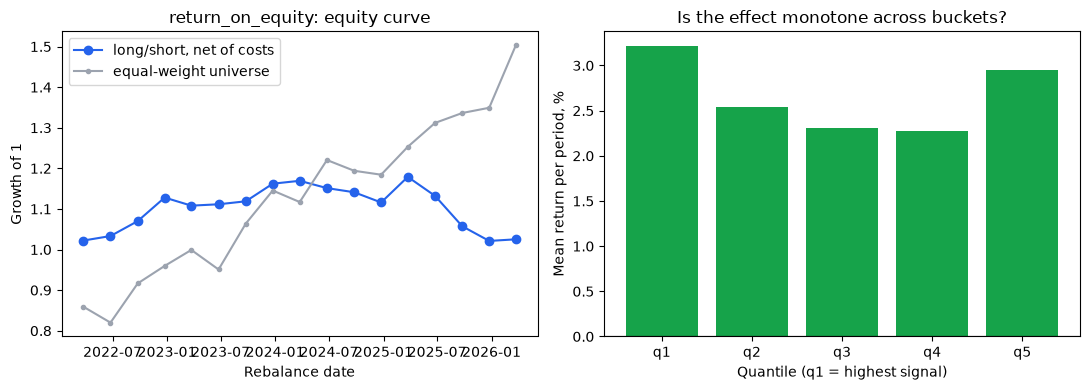

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
curve = result.equity_curve()
axes[0].plot(curve.index, curve.values, color="#2563eb", marker="o", label="long/short, net of costs")
universe_curve = (1 + result.returns["universe_return"]).cumprod()
axes[0].plot(universe_curve.index, universe_curve.values, color="#9ca3af", marker=".", label="equal-weight universe")
axes[0].set_xlabel("Rebalance date")
axes[0].set_ylabel("Growth of 1")
axes[0].set_title(f"{SIGNAL}: equity curve")
axes[0].legend()

q = result.quantile_summary() * 100
axes[1].bar(q.index, q.values, color="#16a34a")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Quantile (q1 = highest signal)")
axes[1].set_ylabel("Mean return per period, %")
axes[1].set_title("Is the effect monotone across buckets?")
plt.tight_layout()
plt.show()

Read the result with its assumptions: one universe (S&P 500), a short window, quarterly
rebalancing, month-end fills. A mean IC near zero, or buckets that are not ordered, means the
ranking did not carry information in this window, whatever the equity curve looks like.

Trying another signal is one line. Any `ratio_name` works:

In [7]:
rows = []
for name in ["return_on_equity", "piotroski_f_score", "net_margin"]:
    p = client.signal_panel(universe, ratios=[name], include_price=False)
    r = backtest(monthly_forward_returns(client, p), signal=name, cost_bps=10.0)
    rows.append({"signal": name, "mean IC": r.mean_ic, "IC-IR": r.ic_ir,
                 "net annualized": r.stats.annualized_return, "sharpe": r.stats.sharpe})
pd.DataFrame(rows).set_index("signal").round(3)

,mean IC,IC-IR,net annualized,sharpe
signal,,,,
return_on_equity,0.015,0.170,0.006,0.119
piotroski_f_score,-0.008,-0.098,-0.032,-0.492
net_margin,0.006,0.078,-0.012,-0.136


## 5. Daily bars and the one-call version (Pro and Institutional)

With `stock_price_daily` on your plan, `client.forward_returns(panel, execution_lag=1)` fills at
the close one trading day after each signal date, and `client.factor_backtest()` runs universe,
signal, returns and backtest in one call. Both record the data snapshot and plan in
`result.provenance`.

In [8]:
if "stock_price_daily" in client.tables():
    daily = client.forward_returns(panel, execution_lag=1)
    print(backtest(daily, signal=SIGNAL, cost_bps=10.0).summary())

    one_call = client.factor_backtest(SIGNAL, start="2022-03-01", end="2026-06-30", freq="QE",
                                      execution_lag=1, cost_bps=10.0)
    print(one_call.summary())
    print(one_call.provenance)
else:
    print(f"Plan '{client.plan}' has no daily bars, so this cell does not run the daily version.\n"
          "With a Pro or Institutional key in VALUEIN_API_KEY it runs:\n"
          "  client.forward_returns(panel, execution_lag=1)\n"
          f"  client.factor_backtest('{SIGNAL}', start='2022-03-01', end='2026-06-30', freq='QE',\n"
          "                         execution_lag=1, cost_bps=10.0)\n"
          "Plans and prices: https://valuein.biz/pricing")

Plan 'sample' has no daily bars, so this cell does not run the daily version.
With a Pro or Institutional key in VALUEIN_API_KEY it runs:
  client.forward_returns(panel, execution_lag=1)
  client.factor_backtest('return_on_equity', start='2022-03-01', end='2026-06-30', freq='QE',
                         execution_lag=1, cost_bps=10.0)
Plans and prices: https://valuein.biz/pricing


In [9]:
client.close()

## Next steps

- **[05 · Prices and total return](05_prices_and_total_return.ipynb)**: why returns must use
  `total_return_index`, shown on a real stock split.
- Script versions: [`python/factor_backtest.py`](../python/factor_backtest.py) (this study) and
  [`python/pit_factor_dataset.py`](../python/pit_factor_dataset.py) (export a point-in-time factor
  dataset to Parquet and CSV).
- The full research workflow, including simulation and offline bundles:
  `help(valuein_sdk.quant)`.